In [1]:
import pandas as pd 
import sys
sys.path.append('../../code')
import plot_of_experiment_data 
import matplotlib.pyplot as plt
import matplotlib
import warnings
import numpy as np 
warnings.filterwarnings("ignore", message="findfont: Font family 'Arial' not found.")
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'

In [4]:
fpath = '/volume_4/research/seongbong/flywire/geosmin_project/LM_data_from_dilan/experiment/inhibitory_neuron_optogenetics/optogenetics_geosmin_pathway_251119.xlsx'

sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
data_df = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df[s] = df
    
data_all = []
pivot_all = []
error_all = []
for s in ['LH1989','LH1990']:
    this_df = data_df[s]
    data,pivot,error =plot_of_experiment_data.make_pivot_optogenetics_data(this_df)
    data_all.append(data)
    pivot_all.append(pivot)
    error_all.append(error)
#     fig,ax = plt.subplots(1,1,figsize=(2,1.8))
#     draw_figure(data,pivot,error)
#     name = f"{s.split(' ')[-1]}>ReachR"
#     ax.set_title(name,fontsize=fontsize,fontstyle='italic')
#     plt.savefig(f'/volume_4/research/seongbong/flywire/geosmin_project/figure/figure6/optogenetics_inhibitory_neurons/figures/{s}.svg',bbox_inches='tight')

In [18]:
data_df['LH1990']

,PER,light,retinal,Unnamed: 3
0,0.6,0,0,a
1,0.5,0,0,b
2,0.8,0,0,c
3,0.6,0,0,d
4,0.7,0,0,e
5,0.7,1,0,a
6,0.5,1,0,b
7,0.6,1,0,c
8,0.7,1,0,d
9,0.7,1,0,e


In [6]:
data_all = {**data_all[0],**{(x[0]+2,x[1]+2):y for x,y in data_all[1].items()}}

pivot_all = pd.concat(pivot_all)
pivot_all.reset_index(inplace=True)

error_all = pd.concat(error_all)
error_all.reset_index(inplace=True)

(0.0, 1.0)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

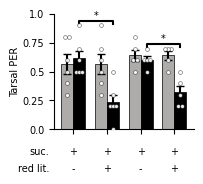

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(1.8, 1.5))

ax, stat_all = plot_of_experiment_data.draw_paired_bar_figure(
    data=data_all,
    mean_df=pivot_all,
    err_df=error_all,
    ax=ax,
    conds=[0, 1, 2, 3],
    groups=['retinal (-)', 'retinal (+)'],
    get_values=lambda data, cond, group: data[
        (cond, 
         {0: {'retinal (-)': 0, 'retinal (+)': 1},
          1: {'retinal (-)': 0, 'retinal (+)': 1},
          2: {'retinal (-)': 2, 'retinal (+)': 3},
          3: {'retinal (-)': 2, 'retinal (+)': 3}}[cond][group])
    ],
    stat_pairs=[
        ((0, 'retinal (+)'), (1, 'retinal (+)')),
        ((2, 'retinal (+)'), (3, 'retinal (+)'))
    ],
    colors=('#AEACAB', 'black'),
    ylabel='Tarsal PER',
    xtick_func=lambda c: '',
    ylim=(0, 0.85),
    yticks=np.round(np.arange(0, 1.25, .25), 2),
    alternative='greater',
    fontsize=7,
    bar_width=0.25,
    bar_spacing=0.7,
    dot_size=7.5,
    stat_fontsize=7
)


sucrose = ['+', '+', '+', '+']
light = ['-', '+', '-', '+']

x_loc = np.arange(0, 4 * 0.7, 0.7)

y_offset = -0.15

ax.text(-0.5, y_offset, 'suc.', fontsize=7, ha='right', va='top')
ax.text(-0.5, y_offset * 2, 'red lit.', fontsize=7, ha='right', va='top')

for i, x in enumerate(x_loc):
    ax.text(x, y_offset, sucrose[i], fontsize=7, ha='center', va='top')
    ax.text(x, y_offset * 2, light[i], fontsize=7, ha='center', va='top')
ax.set_ylim([0,1])

In [19]:
stat_all

[(21.0, 0.015625), (15.0, 0.03125)]